In [1]:
from utils.paths import RAW_DIR,DATABASE_DIR,PREDICTIONS_DIR

from sklearn.preprocessing import StandardScaler,MinMaxScaler
import umap.umap_ as umap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.Descriptors import AlloyDescriptorCalculator
from data.splitting import DataSplitter
from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength


Data correlation experimental data

In [2]:
calc = AlloyDescriptorCalculator()

In [3]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge ---
df_merged = merge_data(df_optical, df_comp)
# --- Filter ---
tern_1550 = filter_by_wavelength(df_merged, 1552.0)
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[['ID','resistivity']])

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [4]:
df_comp = tern_1550[['Cu','Ni','Al','e2','resistivity']]

In [ ]:
descriptor_spec = {
    "atomic_radius": ["avg","mismatch"],
    "metallic_radius": ["avg","mismatch", "range"],
    "electronegativity_pauling": ["avg","mismatch", "range"],
    "electronegativity_allen": ["avg","mismatch", "range"],
    "valence_electrons": ["avg","mismatch", "range"],
    "density": ["avg","mismatch", "range"],
    "electron_affinity": ["avg","mismatch", "range"],
    "ionization_energy_1": ["avg","mismatch", "range"]
}

In [53]:
calc = AlloyDescriptorCalculator()

descriptor_spec = {
    "atomic_radius": ["avg","mismatch"],
    "electronegativity_pauling": ["mismatch"],
    "valence_electrons": ["avg"],
}

#df_desc = calc.transform(df_comp, descriptor_spec=descriptor_spec, include_entropy=True)

In [18]:
corr_pearson = df_desc.corr(numeric_only=True)
target = "e2"

corr_target_pearson = corr_pearson[target].sort_values(ascending=False)
corr_target_pearson = corr_target_pearson.drop(target)

In [22]:
corr_spearman = df_desc.corr(method="kendall",numeric_only=True)
target = "e2"

corr_target_spearman = corr_spearman[target].sort_values(ascending=False)
corr_target_spearman = corr_target_spearman.drop(target)

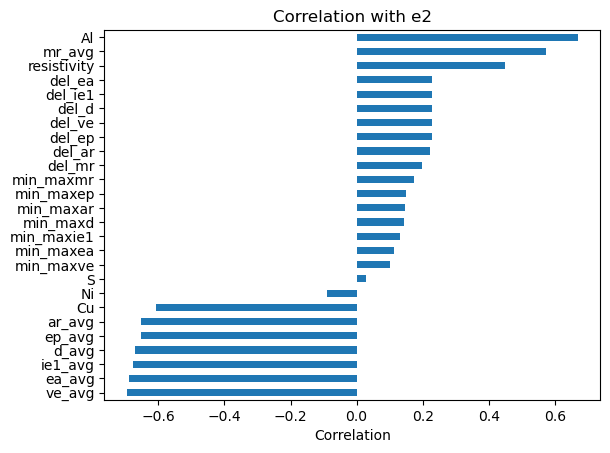

In [ ]:
corr_target_pearson.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Correlation with {target}")
plt.xlabel("Correlation")
plt.show()

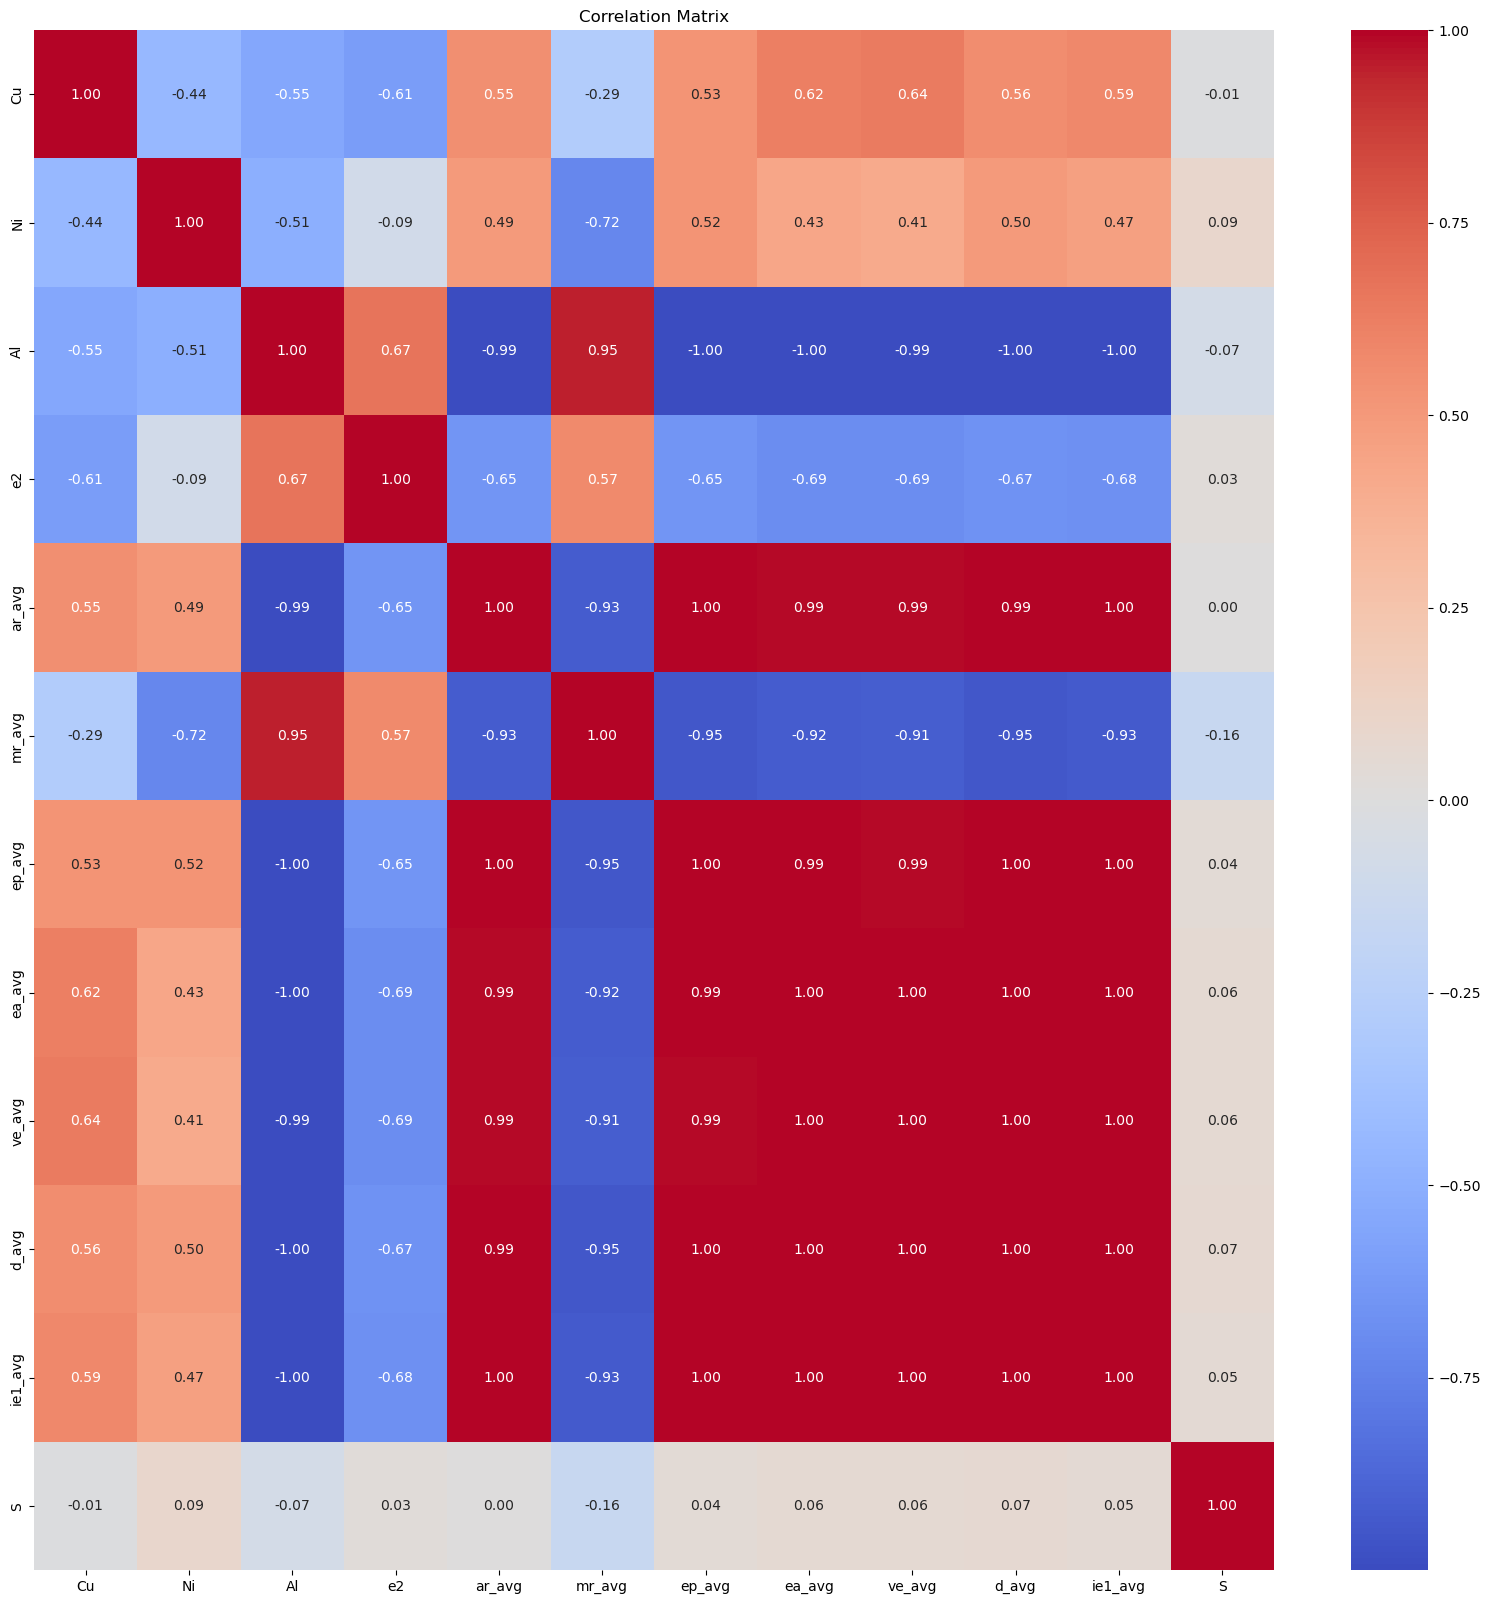

In [7]:
corr = df_desc.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

Data Correlation
1. ANN descriptors with resistivity
2. Experimental data with e2

In [ ]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')

cols = ['r','del_r','del_EN','S','VEC']
ann_data_corr = ann_data[cols]

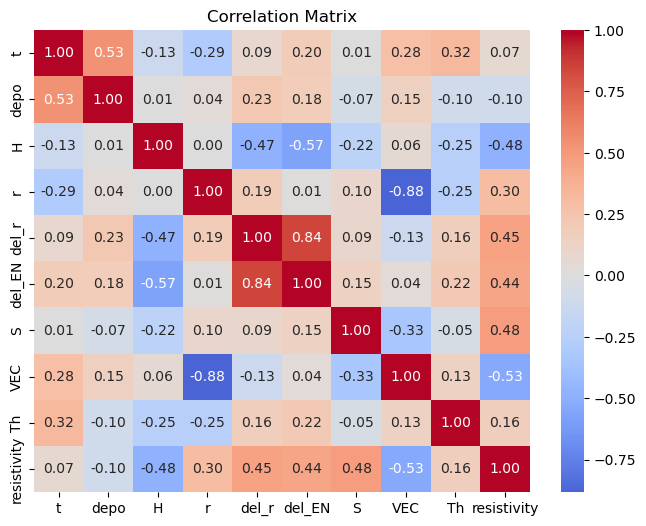

In [3]:
corr = ann_data_corr.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

Clustering CuNiAl system

In [67]:
X = tern_1550[['Cu','Ni','Al','resistivity']].copy()
y = tern_1550['e2'].copy()

splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="cluster",
    n_clusters=5
)

split_dict = splitter.split(X, y)

df_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
df_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

In [68]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")
df_desc = calc.transform(comp_space[['Cu','Ni','Al']], descriptor_spec=descriptor_spec, include_entropy=True)

In [71]:
df_train = df_train.drop(columns=['Cu','Ni','Al','resistivity'])
df_test = df_test.drop(columns=['Cu','Ni','Al','resistivity'])
df_desc = df_desc.drop(columns=['Cu','Ni','Al'])


In [76]:
ann_data = pd.read_csv(RAW_DIR/'Train_ERANN.csv')
cols = ['r','del_r','del_EN','S','VEC']

ann_data = ann_data[cols]

In [82]:
df_train.columns = cols
df_test.columns = cols
df_desc.columns = cols

In [87]:
#df_desc = df_desc.drop(columns='e2')

scaler = MinMaxScaler()
X_ann = scaler.fit_transform(ann_data)
X_all = scaler.transform(df_desc)
X_train = scaler.transform(df_train)
X_test = scaler.transform(df_test)

# UMAP model
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Fit and transform
X_umap_ann = reducer.fit_transform(X_ann)
X_umap = reducer.transform(X_all)
X_umap_train = reducer.transform(X_train)
X_umap_test = reducer.transform(X_test)

# Put into dataframe
df_umap_all = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap_train = pd.DataFrame(X_umap_train, columns=["UMAP1", "UMAP2"])
df_umap_test = pd.DataFrame(X_umap_test, columns=["UMAP1", "UMAP2"])

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


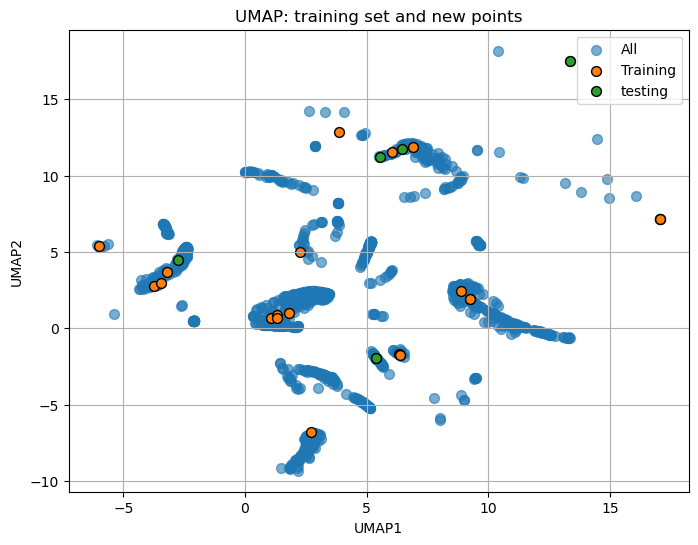

In [89]:
plt.figure(figsize=(8, 6))

# Training points
plt.scatter(
    df_umap_all["UMAP1"],
    df_umap_all["UMAP2"],
    alpha=0.6,
    s=50,
    label="All"
)

# New points
plt.scatter(
    df_umap_train["UMAP1"],
    df_umap_train["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="Training"
)

plt.scatter(
    df_umap_test["UMAP1"],
    df_umap_test["UMAP2"],
    alpha=1.0,
    s=50,
    marker='o',
    edgecolor='black',
    label="testing"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: training set and new points")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
resistivity = pd.read_pickle(PREDICTIONS_DIR/"ANN_Predictions/experimental_resis_prediction.pkl")
resistivity = pd.DataFrame(np.load(PREDICTIONS_DIR/'ANN_Predictions/electrical_resistivity_predicted.npy'))

In [13]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")
comp_space['resistivity'] = np.load(PREDICTIONS_DIR/'ANN_Predictions/electrical_resistivity_predicted.npy')

In [14]:
comp_space.head(5)

,Cu,Ni,Al,r,del_r,del_EN,S,VEC,resistivity
0,0.0,0.00,1.00,1.4300,0.000000,0.000000,-0.000000,3.00,109.452370
1,0.0,0.02,0.98,1.4262,0.018651,0.042000,0.815097,2.98,108.993301
2,0.0,0.04,0.96,1.4224,0.026176,0.058788,1.396288,2.96,104.361984
3,0.0,0.06,0.94,1.4186,0.031808,0.071246,1.887008,2.94,90.669182
4,0.0,0.08,0.92,1.4148,0.036433,0.081388,2.317689,2.92,93.605354


In [16]:
value_Al = comp_space.loc[
    (comp_space["Cu"] == 0) & (comp_space["Ni"] == 0) & (comp_space["Al"] == 1),
    "resistivity"
].values[0]*1e-6

value_Cu = comp_space.loc[
    (comp_space["Cu"] == 1) & (comp_space["Ni"] == 0) & (comp_space["Al"] == 0),
    "resistivity"
].values[0]*1e-6

value_Ni = comp_space.loc[
    (comp_space["Cu"] == 0) & (comp_space["Ni"] == 1) & (comp_space["Al"] == 0),
    "resistivity"
].values[0]*1e-6

In [18]:
print ("Al",f"{value_Al:e}")
print ("Cu",f"{value_Cu:e}")
print ("Ni",f"{value_Ni:e}")

Al 1.094524e-04
Cu 1.648082e-04
Ni 1.338669e-04


In [19]:
a = 273.2115534604162*1e-6
print (f"{a:e}")

2.732116e-04
